# 15 · 학습이 되는지, 비교가 타당한지 확인하기

**완성할 것:** 작은 분류 실험을 데이터 분할 → 학습 통계로 전처리 → 기울기·학습 상태 확인 → 검증으로 설정 선택 → 고정된 test 평가 순서로 수행합니다.
같은 사람의 반복 관측이 섞인 경우, 클래스 불균형, 확률의 정확도, seed 변화도 숫자로 확인합니다.

[02 BCE](../00_기초/02_probability_and_losses.ipynb), [04 미니배치](../00_기초/04_optimizers.ipynb), [14 정규화](14_losses_regularization.ipynb)를 연결합니다.
[그림 보조 코드](../../src/utils/bridge_plots.py), [전체 경로](../../docs/CURRICULUM.md).

**실험에서 정할 것:** 새로운 사람인가 같은 사람의 새 관측인가 → train/validation/test의 단위 → 전처리 학습 범위 → 목적함수와 지표 → 선택 규칙 → 최종 평가.

In [1]:
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src/utils/plotting.py').is_file())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils.bridge_plots import plot_curves, plot_bars, plot_matrices
setup_plots()

'Noto Sans CJK KR'

## 1. 어떤 새 사례에 대한 성능을 묻고 있나요?

120명에게 관측이 4개씩 있다고 합시다. 사람마다 정답 하나가 있고, 같은 사람의 관측은 같은 정답을 공유합니다.
행을 무작위로 나누면 학습에서 본 사람이 검증에도 등장합니다.
사람 ID로 학습 정답을 기억하는 모델은 그 검증에서 높은 점수를 얻을 수 있습니다.
**새로운 사람**의 성능을 알고 싶으면 사람 ID를 분할 단위로 둡니다.

아래 기억 모델은 학습에서 본 사람의 평균 정답을 반환하고, 새 사람에게는 .5를 반환합니다.
평가 질문과 분할 단위를 연결하는 완성 예제입니다.

In [2]:
def memorize_groups(train_groups, train_y, query_groups):
    means = {group: train_y[train_groups == group].mean() for group in np.unique(train_groups)}
    return np.array([means.get(group, .5) for group in query_groups])

In [3]:
rng = np.random.default_rng(150)
group_ids = np.repeat(np.arange(120), 4)
group_labels = np.tile([0, 1], 60)
rng.shuffle(group_labels)
labels = group_labels[group_ids]
row_order = rng.permutation(len(labels))
row_train, row_valid = row_order[:320], row_order[320:]
row_predictions = memorize_groups(group_ids[row_train], labels[row_train], group_ids[row_valid])
row_accuracy = np.mean((row_predictions >= .5) == labels[row_valid])
group_order = rng.permutation(120)
train_group_set, valid_group_set = group_order[:80], group_order[80:]
group_train = np.flatnonzero(np.isin(group_ids, train_group_set))
group_valid = np.flatnonzero(np.isin(group_ids, valid_group_set))
assert len(np.intersect1d(group_ids[group_train], group_ids[group_valid])) == 0
group_predictions = memorize_groups(group_ids[group_train], labels[group_train], group_ids[group_valid])
group_accuracy = np.mean((group_predictions >= .5) == labels[group_valid])
np.testing.assert_allclose(group_predictions, .5)
np.testing.assert_allclose(group_accuracy, labels[group_valid].mean())
row_overlap = len(np.intersect1d(group_ids[row_train], group_ids[row_valid]))
print('행 분할 / 사람 분할 정확도:', row_accuracy, group_accuracy, '행 분할의 겹친 사람 수:', row_overlap)

행 분할 / 사람 분할 정확도: 1.0 0.65 행 분할의 겹친 사람 수: 100


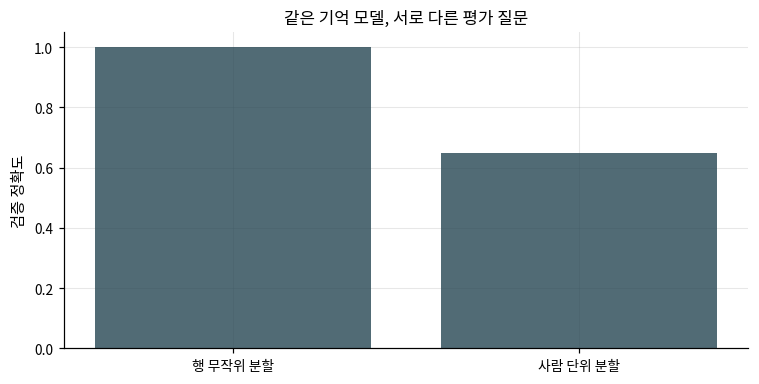

In [4]:
plot_bars(['행 무작위 분할', '사람 단위 분할'], [row_accuracy, group_accuracy],
          title='같은 기억 모델, 서로 다른 평가 질문', ylabel='검증 정확도')

사람 단위 점수는 새 사람에 대한 예측을 측정합니다. 이 기억 모델은 새 사람 모두에게 .5를 주고 임계값 .5에서 양성으로 판정하므로, 이 점수는 검증 그룹의 양성 비율과 같습니다. 같은 사람의 이후 방문을 예측하는 목적이라면 시간 순서와 당시 이용 가능한 정보까지 분할에 반영합니다.
이미지의 같은 원본에서 잘라낸 조각, 동일 문서의 문장, 같은 기기의 시계열도 평가 단위를 먼저 정합니다.

## 2. 전처리도 학습 데이터에서 추정합니다

학습 입력 $X_{train}:(N,D)$의 열별 평균·표준편차를 구해
$\tilde X=(X-\mu_{train})/s_{train}$로 변환합니다.
검증·test에는 같은 $\mu_{train},s_{train}$을 사용합니다. 상수 열의 표준편차는 1로 정해 중심화 값 0을 유지합니다.
이렇게 전처리 파라미터도 학습 과정의 일부로 취급합니다.

In [5]:
def fit_standardizer(X):
    mean = X.mean(axis=0)
    scale = X.std(axis=0)
    scale = np.where(scale < 1e-12, 1., scale)
    return mean, scale


def transform(X, mean, scale):
    return (X - mean) / scale

In [6]:
small_train = np.array([[1., 4.], [3., 4.], [5., 4.]])
small_future = np.array([[100., 4.]])
mean, scale = fit_standardizer(small_train)
np.testing.assert_allclose(mean, [3., 4.])
np.testing.assert_allclose(transform(small_train, mean, scale).mean(axis=0), 0, atol=1e-14)
np.testing.assert_allclose(transform(small_future, mean, scale), [[97/np.sqrt(8/3), 0.]])
all_mean = np.vstack([small_train, small_future]).mean(axis=0)
assert not np.allclose(all_mean, mean)
print('학습 평균:', mean, '미래 관측을 합쳤을 때의 평균:', all_mean)

학습 평균: [3. 4.] 미래 관측을 합쳤을 때의 평균: [27.25  4.  ]


미래 관측을 합치면 학습에서 얻는 값이 달라집니다. 이 예제는 통계의 의존 범위를 드러냅니다.
전처리 전체를 fit/transform으로 나누면 PCA, 특징 선택, 어휘 사전에도 같은 원칙을 적용할 수 있습니다.

## 3. 작은 데이터에서 전체 학습 경로 검산하기

로지스틱 회귀 $z=Xw+b$, $p=\sigma(z)$,
$J=\operatorname{mean}[\log(1+e^z)-yz]+\lambda\|w\|^2/2$를 사용합니다.
$g=(p-y)/N$이면 $dw=X^Tg+\lambda w$, $db=\sum_ng_n$입니다.
`logaddexp(0,z)`는 큰 $z$에서도 안정적으로 $\log(1+e^z)$를 계산합니다.

매 epoch에서 모든 학습 관측을 한 번씩 사용합니다. 마지막 작은 배치에도 그 배치의 관측 수로 평균을 냅니다.
기록은 epoch 끝의 **같은 파라미터**로 전체 train·validation을 평가합니다.
기록할 값은 데이터 BCE, 정규화 포함 목적, 전체 기울기 norm, 해당 epoch의 업데이트 norm 합입니다.

In [7]:
def sigmoid(z):
    return np.exp(-np.logaddexp(0., -z))


def logistic_objective(X, y, w, b, l2=0.):
    logits = X @ w + b
    data_loss = np.mean(np.logaddexp(0., logits) - y*logits)
    g = (sigmoid(logits) - y) / len(y)
    return data_loss + .5*l2*np.sum(w*w), data_loss, X.T @ g + l2*w, g.sum()


def train_logistic(X, y, X_valid, y_valid, *, l2=0., epochs=120, batch_size=64, lr=.08, seed=1):
    local_rng = np.random.default_rng(seed)
    w, b = local_rng.normal(size=X.shape[1]) * .05, 0.
    history = []
    snapshots = []
    for epoch in range(epochs):
        indices = local_rng.permutation(len(y))
        update_norm_sum = 0.
        for start in range(0, len(y), batch_size):
            batch = indices[start:start+batch_size]
            _, _, dw, db = logistic_objective(X[batch], y[batch], w, b, l2)
            update_norm_sum += lr*np.sqrt(np.sum(dw**2)+db**2)
            w -= lr*dw
            b -= lr*db
        objective, train_bce, dw, db = logistic_objective(X, y, w, b, l2)
        valid_bce = logistic_objective(X_valid, y_valid, w, b)[1]
        history.append([train_bce, valid_bce, objective, np.sqrt(np.sum(dw**2)+db**2), update_norm_sum])
        snapshots.append((w.copy(), float(b)))
    history = np.asarray(history)
    best_epoch = int(np.argmin(history[:, 1]))
    return {'w': snapshots[best_epoch][0], 'b': snapshots[best_epoch][1],
            'epoch': best_epoch+1, 'history': history, 'validation_bce': history[best_epoch, 1]}

In [8]:
X_check, y_check = rng.normal(size=(7, 3)), np.array([0., 1., 0., 1., 1., 0., 0.])
w_check, b_check = rng.normal(size=3), np.array(.3)
_, _, dw, db = logistic_objective(X_check, y_check, w_check, b_check, l2=.2)
check_errors = [rel_error(analytic, numerical_gradient(
    lambda: logistic_objective(X_check, y_check, w_check, b_check, l2=.2)[0], parameter))
    for analytic, parameter in [(dw, w_check), (np.array(db), b_check)]]
assert max(check_errors) < 1e-7
X_tiny = np.array([[-2., -1.], [-1., -2.], [1., 2.], [2., 1.]])
y_tiny = np.array([0., 0., 1., 1.])
tiny = train_logistic(X_tiny, y_tiny, X_tiny, y_tiny, epochs=400, batch_size=4)
tiny_prediction = sigmoid(X_tiny @ tiny['w'] + tiny['b'])
assert np.mean((tiny_prediction >= .5) == y_tiny) == 1.
assert tiny['validation_bce'] < .01
print('수치미분 최대 상대 오차:', max(check_errors), '네 관측 BCE:', tiny['validation_bce'])

수치미분 최대 상대 오차: 1.219283239380507e-09 네 관측 BCE: 0.007067326729228688


네 관측에서 손실이 줄어들면 순전파·라벨·역전파·갱신의 연결을 먼저 확인할 수 있습니다.
여기서는 같은 네 관측을 모니터링에 사용한 구현 점검입니다. 다음 실험에서 별도의 검증·test 관측을 사용합니다.

## 4. 설정과 epoch는 검증에서 선택합니다

서로 독립인 관측 900개를 만들고 train 540개, validation 180개, test 180개로 고정합니다.
데이터 생성 seed 151과 분할 seed 152를 별도로 고정합니다. 입력 8개 중 앞의 두 좌표가 라벨 확률을 결정하며, 나머지는 무관한 잡음 좌표입니다.
라벨은 Bernoulli 샘플이므로 입력만으로 정답을 완벽히 맞히기 어려운 관측도 있습니다.

$\lambda\in\{0,.02,.2\}$와 seed 3개를 사용합니다.
각 실행에서 검증 BCE가 가장 작은 epoch의 복사본을 고르고, seed 평균 검증 BCE로 $\lambda$를 선택합니다.
동일 seed는 같은 초기값·배치 순서를 사용해 조건 사이 비교를 짝지어 줍니다.

In [9]:
data_rng = np.random.default_rng(151)
split_rng = np.random.default_rng(152)
raw_X = data_rng.normal(size=(900, 8)) * np.array([3., .5, 2., 1., .2, 4., 1., 2.]) + np.arange(8)
true_logits = 1.2*(raw_X[:, 0]/3) - 1.5*((raw_X[:, 1]-1)/.5) - 1.2
raw_y = (data_rng.random(900) < sigmoid(true_logits)).astype(float)
order = split_rng.permutation(900)
train_index, valid_index, test_index = order[:540], order[540:720], order[720:]
assert len(set(train_index) & set(valid_index)) == 0
assert len(set(train_index) & set(test_index)) == 0
assert len(set(valid_index) & set(test_index)) == 0
train_mean, train_scale = fit_standardizer(raw_X[train_index])
X_train, X_valid = transform(raw_X[train_index], train_mean, train_scale), transform(raw_X[valid_index], train_mean, train_scale)
y_train, y_valid = raw_y[train_index], raw_y[valid_index]
seeds, l2_values = [1, 2, 3], [0., .02, .2]
runs = {l2: [train_logistic(X_train, y_train, X_valid, y_valid, l2=l2, seed=seed) for seed in seeds] for l2 in l2_values}
mean_validation = {l2: np.mean([run['validation_bce'] for run in group]) for l2, group in runs.items()}
selected_l2 = min(mean_validation, key=mean_validation.get)
selected_runs = runs[selected_l2]
print('train/validation 관측 수:', len(y_train), len(y_valid), '양성 비율:', y_train.mean(), y_valid.mean())
print('lambda별 평균 검증 BCE:', mean_validation, '선택 lambda:', selected_l2)
print('선택 epoch:', [run['epoch'] for run in selected_runs])

train/validation 관측 수: 540 180 양성 비율: 0.34814814814814815 0.32222222222222224
lambda별 평균 검증 BCE: {0.0: np.float64(0.4430584554376771), 0.02: np.float64(0.4456812462931811), 0.2: np.float64(0.5036214279992529)} 선택 lambda: 0.0
선택 epoch: [89, 58, 48]


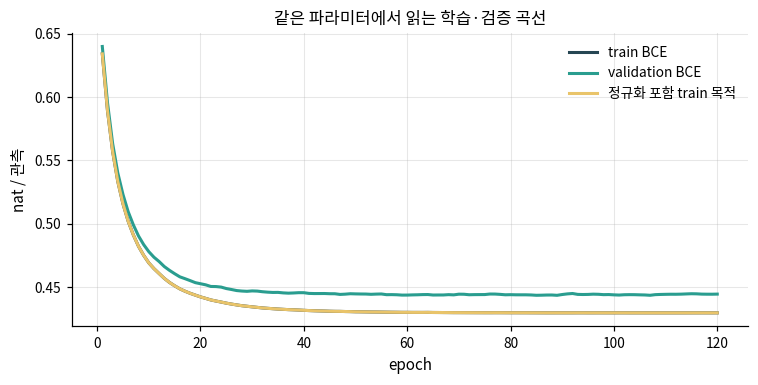

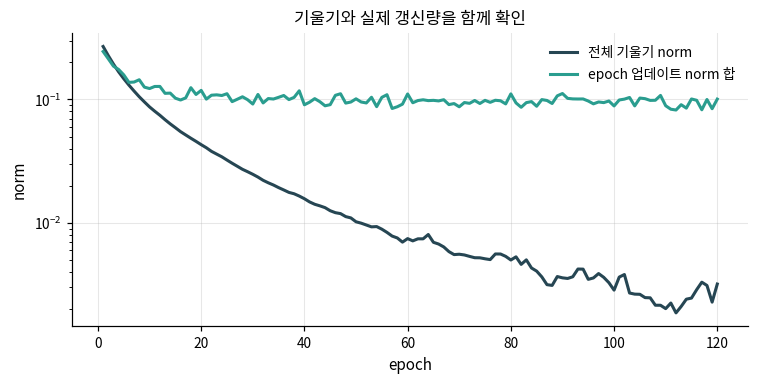

In [10]:
history = selected_runs[0]['history']
epochs = np.arange(1, len(history)+1)
plot_curves(epochs, {'train BCE': history[:, 0], 'validation BCE': history[:, 1], '정규화 포함 train 목적': history[:, 2]},
            title='같은 파라미터에서 읽는 학습·검증 곡선', xlabel='epoch', ylabel='nat / 관측')
plot_curves(epochs, {'전체 기울기 norm': history[:, 3], 'epoch 업데이트 norm 합': history[:, 4]},
            title='기울기와 실제 갱신량을 함께 확인', xlabel='epoch', ylabel='norm', logy=True)

검증 곡선의 최소 위치에서 파라미터를 저장했습니다. 전체 epoch 수는 정해 두고 그 범위 안의 checkpoint를 선택하는 방식입니다.
업데이트 norm의 합은 미니배치 순서와 학습률에 영향을 받습니다. train 전체 기울기 norm과 각각의 의미를 읽습니다.

## 5. 분류와 확률을 다른 지표로 읽기

임계값 $t$에서 $\hat y=1[p\ge t]$로 정합니다. TP·FP·TN·FN은 정답과 예측의 네 조합입니다.
precision은 $TP/(TP+FP)$, recall은 $TP/(TP+FN)$, F1은 $2TP/(2TP+FP+FN)$입니다.
이 실습에서는 분모가 0인 precision·recall·F1 값을 0으로 정합니다.

- **accuracy:** 정답 비율. 양성 비율이 낮으면 음성만 예측해도 큰 값이 될 수 있습니다.
- **BCE/NLL:** 실제 정답에 준 확률의 음의 로그 평균. 틀린 확신에 큰 비용을 줍니다.
- **Brier:** $\operatorname{mean}(p-y)^2$. 예측 확률과 관측의 제곱 차이입니다.
- **ROC-AUC:** 무작위 양성의 점수가 무작위 음성보다 높을 확률에 동점 확률의 절반을 더한 값입니다. 아래에서는 모든 양성·음성 쌍을 직접 비교합니다. 두 클래스가 모두 있을 때 계산합니다. 한 클래스만 관측되면 이 구현은 `np.nan`으로 그 조건을 표시합니다.

AUC는 순위, 임계값 지표는 결정, NLL·Brier는 확률 예측을 평가합니다.

In [11]:
def binary_metrics(y, p, threshold=.5):
    y, p = np.asarray(y), np.asarray(p)
    if y.ndim != 1 or p.shape != y.shape or len(y) == 0:
        raise ValueError('y와 p는 같은 길이의 1차원 배열입니다.')
    if not np.all(np.isin(y, [0, 1])) or np.any(~np.isfinite(p)) or np.any((p < 0) | (p > 1)):
        raise ValueError('y는 0/1이며 p는 [0,1]의 유한한 확률입니다.')
    prediction = p >= threshold
    tp = np.sum((y == 1) & prediction)
    fp = np.sum((y == 0) & prediction)
    tn = np.sum((y == 0) & ~prediction)
    fn = np.sum((y == 1) & ~prediction)
    correct_probability = np.where(y == 1, p, 1-p)
    nll = np.inf if np.any(correct_probability == 0) else -np.log(correct_probability).mean()
    positives, negatives = p[y == 1], p[y == 0]
    auc = np.nan
    if len(positives) and len(negatives):
        differences = positives[:, None] - negatives[None, :]
        auc = np.mean((differences > 0) + .5*(differences == 0))
    return {'accuracy': (tp+tn)/len(y), 'precision': tp/(tp+fp) if tp+fp else 0.,
            'recall': tp/(tp+fn) if tp+fn else 0., 'f1': 2*tp/(2*tp+fp+fn) if 2*tp+fp+fn else 0.,
            'nll': nll, 'brier': np.mean((p-y)**2), 'auc': auc,
            'confusion': np.array([[tn, fp], [fn, tp]])}

In [12]:
hand_y, hand_p = np.array([0, 0, 1, 1]), np.array([.1, .8, .4, .9])
hand_metrics = binary_metrics(hand_y, hand_p)
np.testing.assert_array_equal(hand_metrics['confusion'], [[1, 1], [1, 1]])
for name in ['accuracy', 'precision', 'recall', 'f1']:
    np.testing.assert_allclose(hand_metrics[name], .5)
np.testing.assert_allclose(hand_metrics['auc'], .75)
np.testing.assert_allclose(hand_metrics['brier'], .255)
np.testing.assert_allclose(binary_metrics([0, 1], [.5, .5])['auc'], .5)
assert np.isinf(binary_metrics([0, 1], [1., 0.])['nll'])
print('네 관측 손계산:', {k:v for k,v in hand_metrics.items() if k != 'confusion'})

네 관측 손계산: {'accuracy': np.float64(0.5), 'precision': np.float64(0.5), 'recall': np.float64(0.5), 'f1': np.float64(0.5), 'nll': np.float64(0.6841124189059771), 'brier': np.float64(0.25500000000000006), 'auc': np.float64(0.75)}


### 정확도는 같아도 확신의 정도는 달라집니다

선택한 첫 실행의 검증 logits를 3배하면 0의 어느 쪽인지는 그대로이고 확률은 0·1에 가까워집니다.
임계값 .5의 정확도는 같지만 NLL·Brier는 달라질 수 있습니다.
아래 비교는 **검증 관측에서 확률 지표를 읽는 실험**입니다.

In [13]:
reference_run = selected_runs[0]
validation_logits = X_valid @ reference_run['w'] + reference_run['b']
validation_p = sigmoid(validation_logits)
sharp_p = sigmoid(3*validation_logits)
ordinary_metrics, sharp_metrics = binary_metrics(y_valid, validation_p), binary_metrics(y_valid, sharp_p)
assert ordinary_metrics['accuracy'] == sharp_metrics['accuracy']
print('원래 확률 accuracy/NLL/Brier:', ordinary_metrics['accuracy'], ordinary_metrics['nll'], ordinary_metrics['brier'])
print('logit 3배 accuracy/NLL/Brier:', sharp_metrics['accuracy'], sharp_metrics['nll'], sharp_metrics['brier'])

원래 확률 accuracy/NLL/Brier: 0.8055555555555556 0.4434677231510092 0.14124827418324257
logit 3배 accuracy/NLL/Brier: 0.8055555555555556 0.7084902535875646 0.15887218330438363


**calibration**은 비슷한 확률을 받은 사례에서 실제 양성 비율이 그 확률과 맞는지 살펴보는 성질입니다.
예측 .7 부근인 관측을 모았을 때 실제로 약 70%가 양성이면 그 구간에서 잘 맞는 셈입니다.
구간별 확률 평균과 정답 평균을 계산하고, 구간 크기로 가중한 절대차를 ECE로 요약할 수 있습니다.
이 ECE는 이진 양성 확률을 기준으로 정의하며, 구간 수와 유한한 표본의 영향을 받습니다.

In [14]:
def reliability(y, p, bins=6):
    bin_ids = np.minimum((p*bins).astype(int), bins-1)
    mean_probabilities, frequencies, counts = [], [], []
    for index in range(bins):
        members = bin_ids == index
        if np.any(members):
            mean_probabilities.append(p[members].mean())
            frequencies.append(y[members].mean())
            counts.append(members.sum())
    mean_probabilities, frequencies, counts = map(np.asarray, (mean_probabilities, frequencies, counts))
    ece = np.sum(counts*np.abs(mean_probabilities-frequencies))/len(y)
    return mean_probabilities, frequencies, counts, ece

In [15]:
bin_probabilities, bin_frequencies, bin_counts, ece = reliability(y_valid, validation_p)
print('구간 관측 수:', bin_counts, 'validation ECE:', ece)
thresholds = np.linspace(.1, .9, 33)
mean_validation_probability = np.mean([sigmoid(X_valid @ run['w']+run['b']) for run in selected_runs], axis=0)
threshold_f1 = np.array([binary_metrics(y_valid, mean_validation_probability, t)['f1'] for t in thresholds])
selected_threshold = float(thresholds[np.argmax(threshold_f1)])
print('검증 평균 확률의 F1으로 선택한 임계값:', selected_threshold)

구간 관측 수: [75 34 20 20 18 13] validation ECE: 0.045562456701411125
검증 평균 확률의 F1으로 선택한 임계값: 0.4


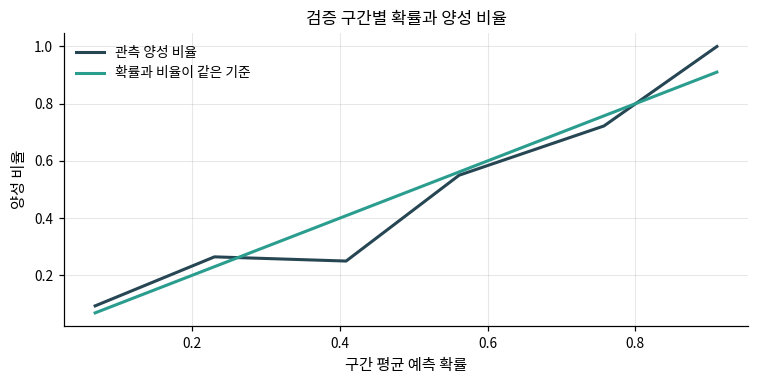

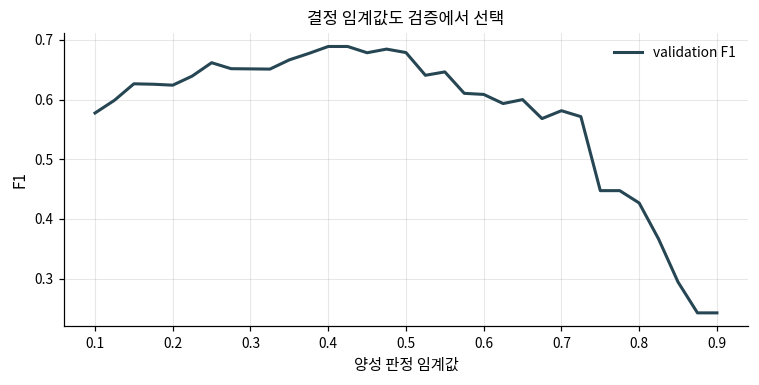

In [16]:
plot_curves(bin_probabilities, {'관측 양성 비율': bin_frequencies, '확률과 비율이 같은 기준': bin_probabilities},
            title='검증 구간별 확률과 양성 비율', xlabel='구간 평균 예측 확률', ylabel='양성 비율')
plot_curves(thresholds, {'validation F1': threshold_f1}, title='결정 임계값도 검증에서 선택', xlabel='양성 판정 임계값', ylabel='F1')

## 6. 선택을 고정하고 test에서 보고하기

지금까지 train은 파라미터·전처리에, validation은 $\lambda$·epoch·임계값 선택에 사용했습니다.
이제 그 선택을 고정하고 test 관측의 결과를 계산합니다.
seed별 표준편차는 **같은 데이터 분할에서 학습 무작위성에 따른 변동**을 요약합니다.
새 데이터 표본으로 바뀔 때의 불확실성은 데이터 재표집·여러 분할·bootstrap 등으로 별도 추정할 수 있습니다.

앞에서 임계값을 고른 대상은 세 실행의 평균 확률입니다. test에서도 그 평균 확률의 결과를 보고하고,
개별 seed의 수치는 공통 임계값 아래에서 학습 변동을 읽는 데 사용합니다.

In [17]:
X_test, y_test = transform(raw_X[test_index], train_mean, train_scale), raw_y[test_index]
test_probabilities = [sigmoid(X_test @ run['w']+run['b']) for run in selected_runs]
test_results = [binary_metrics(y_test, p, selected_threshold) for p in test_probabilities]
ensemble_probability = np.mean(test_probabilities, axis=0)
ensemble_result = binary_metrics(y_test, ensemble_probability, selected_threshold)
for seed, run, metrics in zip(seeds, selected_runs, test_results):
    print(f"seed={seed}, epoch={run['epoch']}, test NLL={metrics['nll']:.6f}, accuracy={metrics['accuracy']:.4f}, F1={metrics['f1']:.4f}, AUC={metrics['auc']:.4f}")
seed_nll = np.array([metrics['nll'] for metrics in test_results])
print('seed NLL 평균 / 표본 표준편차:', seed_nll.mean(), seed_nll.std(ddof=1))
print('세 실행 평균 확률 test:', {k:v for k,v in ensemble_result.items() if k != 'confusion'})

seed=1, epoch=89, test NLL=0.429953, accuracy=0.7722, F1=0.6095, AUC=0.8319
seed=2, epoch=58, test NLL=0.429226, accuracy=0.7778, F1=0.6154, AUC=0.8322
seed=3, epoch=48, test NLL=0.429568, accuracy=0.7833, F1=0.6355, AUC=0.8309
seed NLL 평균 / 표본 표준편차: 0.42958233052221834 0.0003638927795710818
세 실행 평균 확률 test: {'accuracy': np.float64(0.7722222222222223), 'precision': np.float64(0.5245901639344263), 'recall': np.float64(0.7272727272727273), 'f1': np.float64(0.6095238095238096), 'nll': np.float64(0.4294734341320058), 'brier': np.float64(0.14156076477094362), 'auc': np.float64(0.8322192513368984)}


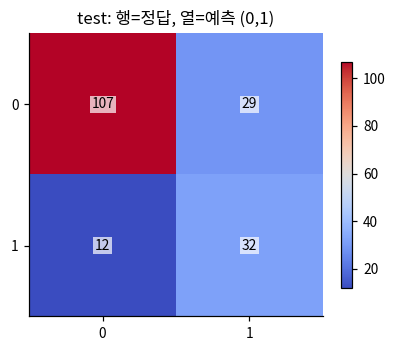

In [18]:
plot_matrices([ensemble_result['confusion']], ['test: 행=정답, 열=예측 (0,1)'])

### 조건을 바꾸는 실험은 무엇을 측정하나요?

학습한 모델을 그대로 두고 validation의 첫 번째 특성만 섞으면 예측이 그 특성에 얼마나 의존하는지 살펴볼 수 있습니다.
여기서는 앞의 두 특성만 라벨 생성에 쓰였으므로, 첫 번째 특성과 여덟 번째 잡음 특성을 비교합니다.
이 **순열 실험**은 모델을 재학습하는 feature 제거 실험과 구분해 기록합니다.
분포 변화에서는 입력 관계 자체가 달라질 수 있으므로 원래 validation과 변화된 입력의 점수를 함께 읽습니다.

In [19]:
permutation_rng = np.random.default_rng(159)
permutation = permutation_rng.permutation(len(y_valid))
permuted_nll = {}
for column in [0, 7]:
    changed_X = X_valid.copy()
    changed_X[:, column] = changed_X[permutation, column]
    changed_p = sigmoid(changed_X @ reference_run['w'] + reference_run['b'])
    permuted_nll[column] = binary_metrics(y_valid, changed_p)['nll']
print('원래 validation NLL:', ordinary_metrics['nll'], '특성별 순열 NLL:', permuted_nll)

원래 validation NLL: 0.4434677231510092 특성별 순열 NLL: {0: np.float64(0.6937559796926076), 7: np.float64(0.44775356397494714)}


## 7. 직접 바꾸기: 같은 확률에서 지표 다시 만들기

`my_binary_metrics(y, p, threshold=.5)`를 작성해 위 함수와 같은 키의 dictionary를 반환해 보세요.
손계산 가능한 관측에서 시작해 동점·양성 예측 0개·확률 0·1을 포함합니다.
검사 이후에는 `raw_y` 생성식의 절편을 $-1.2$에서 $-2.5$로 바꾸고, **새 실험의 분할부터** 다시 실행해 보세요.
양성 비율·정확도·recall·선택 임계값을 한 표로 기록하면 불균형의 영향을 읽을 수 있습니다.

In [20]:
def check_binary_metrics(candidate):
    cases = [
        (np.array([0, 0, 1, 1]), np.array([.1, .8, .4, .9]), .5),
        (np.array([0, 1, 1, 0]), np.array([.5, .5, .2, .1]), .7),
        (np.array([0, 1]), np.array([0., 1.]), .5),
        (np.array([0, 1]), np.array([1., 0.]), .5),
        (np.array([0, 1]), np.array([.5, .5]), .5),  # 임계값과 같은 확률
        (np.array([1, 1, 1, 0]), np.array([.9, .4, .3, .2]), .5),  # precision과 recall이 다름
        (np.array([0, 0, 0]), np.array([.1, .2, .8]), .5),  # 한 클래스의 AUC 규약
        (np.array([1, 1]), np.array([.1, .2]), .5),
    ]
    for y, p, threshold in cases:
        actual = candidate(y.copy(), p.copy(), threshold)
        expected = binary_metrics(y, p, threshold)
        assert isinstance(actual, dict) and expected.keys() <= actual.keys()
        for key, reference in expected.items():
            assert np.shape(actual[key]) == np.shape(reference), key
            np.testing.assert_allclose(actual[key], reference, atol=1e-12, err_msg=key)
    return '통과: 혼동행렬·임계값·동점 순위·분모 규약·확률 지표'

In [21]:
print(check_binary_metrics(binary_metrics))
# 재실행 후 기록할 실험 정보를 결과 값과 함께 한곳에 모읍니다.
experiment_record = {
    'data_seed': 151, 'split_seed': 152, 'train_validation_test_counts': [540, 180, 180],
    'l2_candidates': l2_values, 'training_seeds': seeds,
    'selected_l2': selected_l2, 'selected_epochs': [run['epoch'] for run in selected_runs],
    'selected_threshold': selected_threshold, 'selection_metric': 'validation BCE then ensemble validation F1',
    'test_ensemble_nll': ensemble_result['nll'], 'test_ensemble_f1': ensemble_result['f1'],
    'test_seed_nll_std': float(seed_nll.std(ddof=1)),
}
print(experiment_record)

통과: 혼동행렬·임계값·동점 순위·분모 규약·확률 지표
{'data_seed': 151, 'split_seed': 152, 'train_validation_test_counts': [540, 180, 180], 'l2_candidates': [0.0, 0.02, 0.2], 'training_seeds': [1, 2, 3], 'selected_l2': 0.0, 'selected_epochs': [89, 58, 48], 'selected_threshold': 0.4, 'selection_metric': 'validation BCE then ensemble validation F1', 'test_ensemble_nll': np.float64(0.4294734341320058), 'test_ensemble_f1': np.float64(0.6095238095238096), 'test_seed_nll_std': 0.0003638927795710818}


**준비도 확인**

- 새 사람·새 시점·새 문서 중 무엇을 예측하는지 정하고 분할 단위를 만들 수 있나요?
- 전처리 파라미터와 모델 파라미터가 어느 데이터에서 학습되는지 추적할 수 있나요?
- 작은 데이터 학습과 별도 validation 평가의 목적을 각각 설명할 수 있나요?
- accuracy·NLL·Brier·AUC가 같은 예측의 어떤 성질을 읽는지 손계산할 수 있나요?
- $\lambda$·epoch·임계값을 고정한 뒤 test 결과와 seed 변동을 기록할 수 있나요?

다음은 [전체 경로](../../docs/CURRICULUM.md)의 구조 조합 또는 Autoencoder 경로입니다.
새 모델에서도 이 실험 순서를 사용하며, 생성·표현·RL의 목적에 맞는 지표를 추가합니다.

공식 참고: [scikit-learn의 데이터 누출과 전처리 안내](https://scikit-learn.org/stable/common_pitfalls.html),
[분류 확률 calibration 안내](https://scikit-learn.org/stable/modules/calibration.html).
이 노트북의 분할·학습·지표 계산은 NumPy로 본문에 구현했습니다.